# 🎵 Music Generation Using Recurrent Neural Networks (RNN)
### Student Laboratory Notebook

---

| Field | Details |
|-------|---------|
| **Course** | Deep Learning Lab |
| **Topic** | Sequence Modelling — Music Generation with RNN |
| **Dataset** | MIDI Music Files (Nottingham / Custom) |
| **Framework** | TensorFlow / Keras |
| **Notation** | Prof. Mitesh Khapra (CS7015, IIT Madras) |

---

## 📌 Objective

In this experiment you will:
1. Understand how music can be represented as a **sequence of discrete tokens** (notes/chords)
2. Build a **character-level RNN** that learns musical patterns
3. Train the model to **generate new music sequences** note by note
4. Analyse the effect of **temperature (τ)** on creativity vs coherence
5. Optionally convert generated sequences back to **playable MIDI audio**

---

## 📐 Notation Reference (Mitesh Khapra, CS7015)

| Symbol | Meaning |
|--------|---------|
| $x_t$ | Input token (note/chord) at time step $t$ |
| $s_t$ | Hidden state at time $t$ |
| $W$ | Input-to-hidden weight matrix |
| $U$ | Hidden-to-hidden (recurrent) weight matrix |
| $V$ | Hidden-to-output weight matrix |
| $b_s$, $b_y$ | Bias vectors |
| $\hat{y}_t$ | Predicted output distribution over notes |
| $\tau$ | Temperature for sampling |

**RNN Equations:**
$$s_t = \tanh(W \cdot x_t + U \cdot s_{t-1} + b_s)$$
$$\hat{y}_t = \text{softmax}(V \cdot s_t + b_y)$$

---

## ⚠️ Instructions to Students

- **Do NOT modify** the section headings or question cells.
- Fill in all cells marked with `# YOUR CODE HERE` or `# YOUR ANSWER HERE`.
- Answer all written questions in the **Markdown Answer cells** provided below each question.
- Run cells **in order** from top to bottom.
- Save your completed notebook as: `RollNumber_MusicGen_RNN.ipynb`

---

---
# 📦 Section 1: Environment Setup & Library Imports
---

### 🔷 Background

Before building any model, we must prepare our Python environment. For music generation we need:
- `music21` — a toolkit for parsing and writing MIDI files
- `tensorflow` / `keras` — for building and training the RNN
- `numpy`, `matplotlib` — for data manipulation and visualisation

> **MIDI (Musical Instrument Digital Interface):** A standard protocol that represents music as a sequence of events — notes, durations, velocities — rather than raw audio. Each note can be encoded as an integer, making MIDI ideal for sequence modelling.

In [1]:
# Install required libraries (run once)
!pip install music21 --quiet

In [2]:
# ── Standard imports ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import os, glob, pickle

# ── Deep learning ────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Music processing ─────────────────────────────────────────
from music21 import converter, instrument, note, chord, stream

print("TensorFlow :", tf.__version__)
print("All libraries loaded successfully ✓")

TensorFlow : 2.19.0
All libraries loaded successfully ✓


### ❓ Question 1.1 — Conceptual Understanding

**Why is MIDI a better representation for music generation with an RNN compared to raw audio (WAV/MP3)?  
Discuss in terms of sequence length, vocabulary size, and computational cost.**

> 💡 *Hint: Think about the sampling rate of audio (44,100 samples/sec) vs the number of discrete MIDI note events per second.*

MIDI is better than raw audio for RNN music generation because:

* **Shorter sequence:** MIDI has fewer note events, while audio has thousands of samples per second.
* **Smaller vocabulary:** MIDI uses limited notes, but audio has many continuous values.
* **Less computation:** MIDI is simple and fast to process, while audio needs high memory and time.

So, MIDI is easier for the model to learn and generate music.


---
# 🎼 Section 2: Dataset Loading & MIDI Parsing
---

### 🔷 Background

We use the **Nottingham Music Dataset** — a collection of 1,000+ folk tunes in MIDI format.  
You can also use your own MIDI files.

Each MIDI file is parsed into a flat list of **note/chord strings**, for example:

```
['C4', 'E4', 'G4', 'E.G.C5', 'D4', 'F4', ...]
```

Where:
- `'C4'` = single note C in octave 4
- `'E.G.C5'` = chord containing notes E, G, C5 (dot-separated)

**Dataset Download:**  
Place your `.mid` files inside a folder called `midi_songs/` in your working directory.  
Or use the Nottingham dataset: https://github.com/jukedeck/nottingham-dataset

In [18]:
from google.colab import files

uploaded = files.upload()
import zipfile

zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall()

Saving midi_songs.zip.zip to midi_songs.zip (1).zip


In [21]:
MIDI_FOLDER = 'MIDI/'
notes = parse_midi_files(MIDI_FOLDER)

print(len(notes))

Found 1034 MIDI files.
Total notes/chords extracted: 248,464
248464


In [22]:
import pickle

with open("notes.pkl", "wb") as f:
    pickle.dump(notes, f)

### ❓ Question 2.1 — Data Exploration

**After parsing your MIDI files, answer the following:**

1. How many unique notes/chords are in your dataset? (This is your vocabulary size $|\mathcal{V}|$)
2. What is the total sequence length $N$?
3. List the **5 most frequent** notes/chords in your dataset.
4. Why does vocabulary size $|\mathcal{V}|$ matter for the RNN's output layer?

> 💡 *Use Python's `collections.Counter` to find frequencies.*

In [23]:
from collections import Counter

# 1. Vocabulary size (unique notes/chords)
vocab_size = len(set(notes))

# 2. Total sequence length
N = len(notes)

# 3. Top 5 most frequent tokens
counter = Counter(notes)
top5 = counter.most_common(5)

print(f"Vocabulary size  |V| = {vocab_size}")
print(f"Total tokens       N = {N}")
print(f"Top 5 tokens         = {top5}")

Vocabulary size  |V| = 130
Total tokens       N = 248464
Top 5 tokens         = [('D5', 27554), ('A4', 26388), ('B4', 23517), ('E5', 20481), ('G4', 15812)]


**✏️ Your Written Answer (Q2.1.4 — Why does |V| matter?):**

```
Vocabulary size matters because the RNN must choose the next note from all possible notes.

So, the output layer has one neuron for each note in the vocabulary. If the vocabulary is large, the model becomes more complex and needs more computation.

```

### ❓ Question 2.2 — Visualisation

**Plot a bar chart of the top 20 most frequent notes/chords in your dataset.**  
Label your axes clearly. What musical pattern do you observe from the distribution?

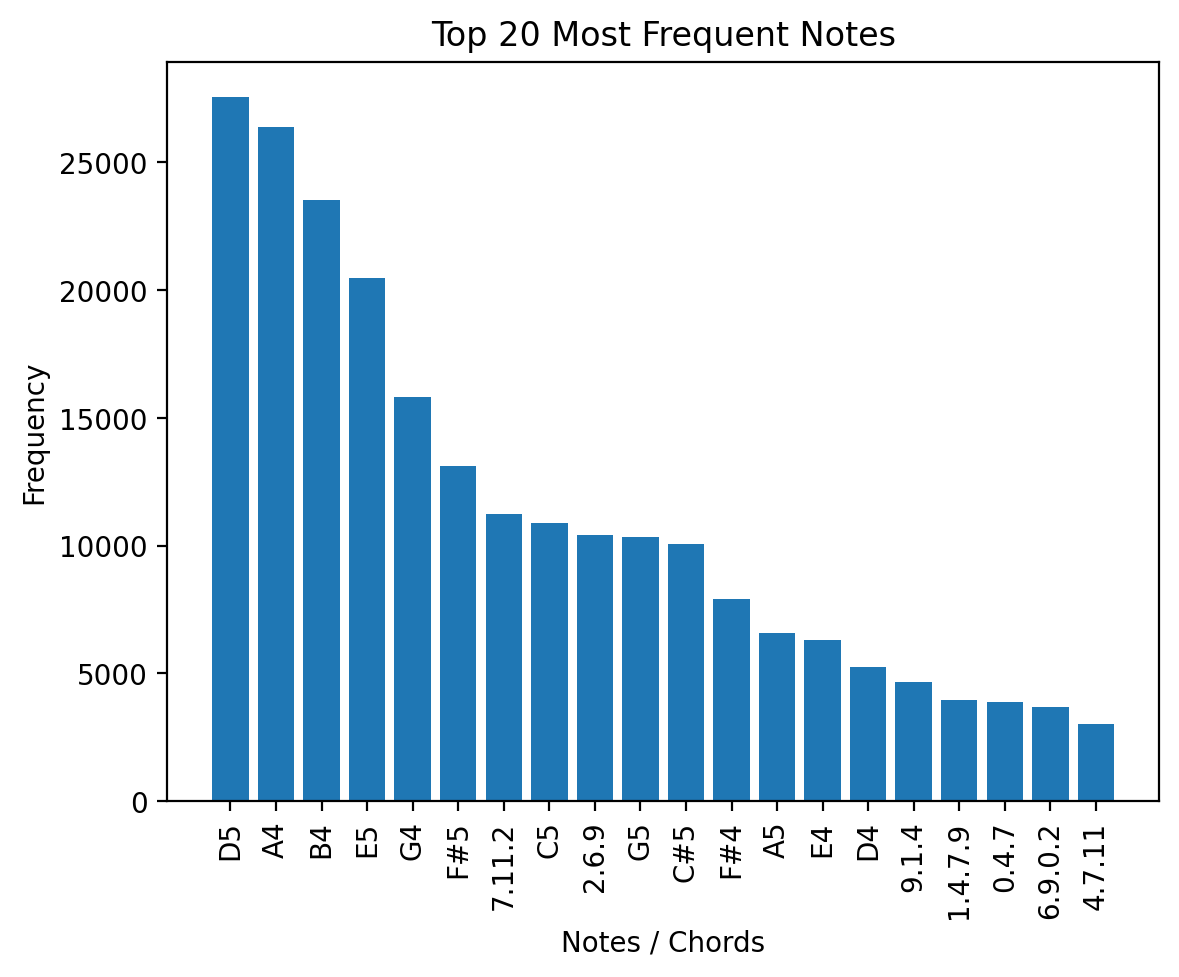

In [24]:
import matplotlib.pyplot as plt
from collections import Counter

# Count frequencies
counter = Counter(notes)

# Get top 20
top20 = counter.most_common(20)

# Separate notes and counts
notes_list = [x[0] for x in top20]
counts = [x[1] for x in top20]

# Plot
plt.figure()
plt.bar(notes_list, counts)
plt.xticks(rotation=90)
plt.xlabel("Notes / Chords")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Notes")
plt.show()

**✏️ Your Observation:**

```
The distribution is not uniform, it is skewed. Some notes appear much more frequently than others.

This shows that in music, certain notes and chords are used more often, forming common patterns and structures. Music is not random; it follows specific rules and repetitions.

```

---
# 🔢 Section 3: Vocabulary & Sequence Encoding
---

### 🔷 Background

Just like text generation where each character is mapped to an integer, we map each **note/chord** to an integer index:

$$\text{note\_to\_int}: \mathcal{V} \rightarrow \{0, 1, \ldots, |\mathcal{V}|-1\}$$

Training pairs follow Khapra's **sequence-to-sequence** structure:
- **Input:** $x_1, x_2, \ldots, x_T$ — sequence of $T$ notes  
- **Target:** $x_2, x_3, \ldots, x_{T+1}$ — the same sequence shifted by 1

The model learns: **given the last $T$ notes, predict the next note**.

In [25]:
# Build vocabulary mappings
vocab        = sorted(set(notes))
vocab_size   = len(vocab)
note_to_int  = {n: i for i, n in enumerate(vocab)}
int_to_note  = {i: n for i, n in enumerate(vocab)}

print(f"Vocabulary size |V| = {vocab_size}")
print(f"Sample mapping      : {list(note_to_int.items())[:8]}")

Vocabulary size |V| = 130
Sample mapping      : [('0.2.3.6.9', 0), ('0.3', 1), ('0.3.6', 2), ('0.3.6.8', 3), ('0.3.7', 4), ('0.4', 5), ('0.4.7', 6), ('0.4.8', 7)]


In [26]:
# ---- Step 0: Imports ----
import numpy as np
import tensorflow as tf

# ---- Step 1: Hyperparameters ----
T = 100   # sequence length
B = 64    # batch size

# ---- Step 2: Build vocabulary (make sure notes exists) ----
vocab        = sorted(set(notes))
vocab_size   = len(vocab)
note_to_int  = {n: i for i, n in enumerate(vocab)}
int_to_note  = {i: n for i, n in enumerate(vocab)}

# ---- Step 3: Encode notes ----
encoded = np.array([note_to_int[n] for n in notes])

# ---- Step 4: Create tf.data dataset ----
data = tf.data.Dataset.from_tensor_slices(encoded)

# ---- Step 5: Create sliding windows (T+1) ----
sequences = data.window(T+1, shift=1, drop_remainder=True)
sequences = sequences.flat_map(lambda x: x.batch(T+1))

# ---- Step 6: Split into input and target ----
def split_input_target(seq):
    x = seq[:-1]   # input
    y = seq[1:]    # target (shifted)
    return x, y

dataset = sequences.map(split_input_target)

# ---- Step 7: Shuffle, batch, prefetch ----
dataset = dataset.shuffle(10000).batch(B).prefetch(tf.data.AUTOTUNE)

# ---- Step 8: Verify shapes ----
for x_batch, y_batch in dataset.take(1):
    print(f"Input  shape: {x_batch.shape}   → (B={B}, T={T})")
    print(f"Target shape: {y_batch.shape}   → (B={B}, T={T})")

Input  shape: (64, 100)   → (B=64, T=100)
Target shape: (64, 100)   → (B=64, T=100)


### ❓ Question 3.1 — Sequence Design

**Answer the following about your sequence construction:**

1. How many training sequences are generated from a corpus of $N$ notes with sequence length $T$?  
   Write the formula and compute it for your dataset.
2. Why is the target sequence **shifted by 1** relative to the input?
3. If $T$ is too small (e.g., $T=5$), what musical problem might the model have? If $T$ is too large (e.g., $T=500$)?
4. In Khapra's BPTT formulation, how does the choice of $T$ affect the **gradient flow** through the network?

**✏️ Your Answers:**

1. *(Formula + computed value)*

```
The number of sequences generated is:
N − T

Because for each sequence of length T, we need T+1 notes to create input and target.
```

2. *(Why shift by 1?)*

```
The target is shifted by 1 so that the model learns to predict the next note.
Input = current notes, Target = next notes.
```

3. *(Effect of T too small / too large)*

```
The model cannot capture long-term musical patterns, so generated music may sound random or incomplete.
If T is too large
```

4. *(Effect on BPTT gradient flow)*

```
T determines how far back gradients are propagated.
Large T → gradients flow through many steps (may vanish/explode).
Small T → limited learning of long-term dependencies.
```

---
# 🏗️ Section 4: Building the RNN Model
---

### 🔷 Background — Khapra Architecture

We implement the exact architecture from **Prof. Mitesh Khapra's CS7015 Lecture 10**:

```
x_t (note index)
    │
    ▼
┌─────────────────────────────────────────┐
│  Embedding:  e_t = W_embed · x_t       │   e_t ∈ R^d
└─────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────┐
│  SimpleRNN:                             │
│  s_t = tanh(W·e_t + U·s_{t-1} + b_s)  │   s_t ∈ R^H
└─────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────┐
│  Dense:  ŷ_t = V·s_t + b_y            │   ŷ_t ∈ R^|V|
└─────────────────────────────────────────┘
    │
    ▼
  softmax → probability over all notes
```

**Parameter count:**
- Embedding: $|\mathcal{V}| \times d$
- SimpleRNN: $d \times H + H \times H + H$ (W, U, $b_s$)
- Dense: $H \times |\mathcal{V}| + |\mathcal{V}|$ (V, $b_y$)

In [27]:
print(len(notes))

248464


In [28]:
from tensorflow.keras import layers, Model

def build_music_rnn(vocab_size: int,
                    d: int,
                    H: int,
                    T: int,
                    batch_size=None,
                    stateful: bool = False):

    # Step 1: Input layer
    inputs = layers.Input(shape=(T,), batch_size=batch_size)

    # Step 2: Embedding layer
    x = layers.Embedding(input_dim=vocab_size,
                         output_dim=d,
                         name='embedding_W')(inputs)

    # Step 3: SimpleRNN layer
    x = layers.SimpleRNN(units=H,
                         return_sequences=True,
                         stateful=stateful,
                         name='s_t_rnn')(x)

    # Step 4: Dense layer (logits)
    outputs = layers.Dense(units=vocab_size,
                           name='y_hat_logits')(x)

    # Step 5: Build model
    model = Model(inputs, outputs)

    return model


# ---- Hyperparameters (make sure defined) ----
T = 100
B = 64
d = 256
H = 512

# ---- Build model ----
model = build_music_rnn(vocab_size, d, H, T)

# ---- Show summary ----
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_W (Embedding)         │ (None, 100, 256)       │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_t_rnn (SimpleRNN)             │ (None, 100, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_hat_logits (Dense)            │ (None, 100, 130)       │        66,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493,698 (1.88 MB)

 Trainable params: 493,698 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.1 — Model Architecture

**Using your `model.summary()` output, answer the following:**

1. Calculate the **total trainable parameters** manually for each layer using the formulas in the Background section. Do they match `model.summary()`?
2. What is the **role of the Embedding layer** in this architecture? Could we use one-hot encoding instead? What would be the disadvantage?
3. Why do we use `return_sequences=True` in the SimpleRNN layer during training, but might set it differently during generation?

**✏️ Your Answers:**

1. *(Manual parameter count)*

```
Embedding : __130___ × __256__ = 33280________
SimpleRNN : __256___ × 512____ + 512_____ × _512____ + __512___ = 393728________
Dense     : __512___ × _130____ + __130___ = 66,690________
TOTAL     : __493,698______
```

2. *(Role of Embedding vs One-Hot)*

```
The Embedding layer converts each note (integer index) into a dense vector representation, capturing relationships between notes.

Yes, we can use one-hot encoding, but it is inefficient because it creates very large sparse vectors and increases computation. Embedding is more compact and efficient.
```

3. *(return_sequences=True during training vs generation)*

```
We use return_sequences=True during training because we need predictions at every time step.

During generation, we may only need the final output to predict the next note, so it can be set to False.
```

### ❓ Question 4.2 — Stacked RNN (Extension)

**Add a second SimpleRNN layer with $H = 256$ on top of the first layer.**
- Name it `'s_t_rnn_2'`
- Print the new `model.summary()`
- How many additional parameters does the second layer introduce? Compute manually.
- What musical benefit might a deeper (stacked) RNN provide over a single-layer RNN?

In [29]:
from tensorflow.keras import layers, Model

def build_stacked_rnn(vocab_size, d, T):

    inputs = layers.Input(shape=(T,))

    # Embedding
    x = layers.Embedding(input_dim=vocab_size,
                         output_dim=d,
                         name='embedding_W')(inputs)

    # First RNN layer
    x = layers.SimpleRNN(512,
                         return_sequences=True,
                         name='s_t_rnn')(x)

    # Second RNN layer (NEW)
    x = layers.SimpleRNN(256,
                         return_sequences=True,
                         name='s_t_rnn_2')(x)

    # Dense layer
    outputs = layers.Dense(vocab_size,
                           name='y_hat_logits')(x)

    model = Model(inputs, outputs)
    return model


# Build model
model = build_stacked_rnn(vocab_size, d, T)

# Summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_W (Embedding)         │ (None, 100, 256)       │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_t_rnn (SimpleRNN)             │ (None, 100, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_t_rnn_2 (SimpleRNN)           │ (None, 100, 256)       │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_hat_logits (Dense)            │ (None, 100, 130)       │        33,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 657,282 (2.51 MB)

 Trainable params: 657,282 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

**✏️ Your Answer (Musical benefit of stacked RNN):**

```

```

---
# 📉 Section 5: Loss Function & Compilation
---

### 🔷 Background

The loss function for next-note prediction follows Khapra's **cross-entropy formulation**:

$$\mathcal{L} = -\frac{1}{T} \sum_{t=1}^{T} \log \hat{y}_t^{(x_{t+1})}$$

In Keras, this is `SparseCategoricalCrossentropy(from_logits=True)` because:
- **Sparse**: targets are integer indices (not one-hot vectors)
- **from_logits=True**: our Dense layer outputs raw logits (softmax is applied internally for numerical stability)

**Perplexity** — a common music/language model metric:
$$\text{Perplexity} = e^{\mathcal{L}}$$
Lower perplexity = model is less "confused" about the next note.

In [30]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(
    loss=SparseCategoricalCrossentropy(from_logits=True),
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Model compiled ✓")

Model compiled ✓


### ❓ Question 5.1 — Loss & Metrics

1. What does `from_logits=True` mean? Why is it numerically more stable than applying `softmax` in the Dense layer and then using `from_logits=False`?
2. Suppose your model achieves a loss of $\mathcal{L} = 2.3$ after training. What is the perplexity? What does this value mean musically?
3. Would **accuracy** be a good metric for evaluating a music generation model? Why or why not? Suggest a better evaluation approach.

**✏️ Your Answers:**

1.
```
from_logits=True:
It means the model outputs raw scores (logits) instead of probabilities. Softmax is applied internally inside the loss function.

It is numerically more stable because it avoids very large or very small values that can occur when applying softmax separately, reducing floating-point errors
```

2.
```
Perplexity = e^L = e^2.3 ≈ 9.97 (≈ 10)

This means the model is, on average, choosing between about 10 possible notes at each step. Lower perplexity indicates better and more confident predictions.
```

3.
```
Accuracy is not a good metric for music generation because music can have multiple correct next notes, and creativity is important.

A better evaluation approach is to use:

Perplexity (to measure prediction confidence)
Listening evaluation (human judgment of generated music quality)

```

---
# 🏋️ Section 6: Training the Model (BPTT)
---

### 🔷 Background — BPTT

Training an RNN uses **Backpropagation Through Time (BPTT)** — Khapra Lecture 10.

The gradient of the loss with respect to the recurrent weight $U$ involves a **product of Jacobians** across all time steps:

$$\frac{\partial \mathcal{L}}{\partial U} = \sum_{t=1}^{T} \sum_{k=1}^{t} \delta_t \cdot \left(\prod_{j=k+1}^{t} \text{diag}(1 - s_j^2) \cdot U \right) \cdot s_{k-1}^{\top}$$

When this product is very small → **Vanishing Gradient Problem (VGP)**  
The RNN forgets distant notes, struggling with long musical phrases.

**Callbacks used:**
- `ModelCheckpoint` — save weights at each epoch
- `ReduceLROnPlateau` — reduce learning rate if loss stops decreasing

In [34]:
import os
os.makedirs("checkpoints", exist_ok=True)

# Callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="checkpoints/music_rnn_epoch_{epoch:02d}.weights.h5",
    save_weights_only=True,
    verbose=1
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

# ── YOUR CODE HERE ────────────────────────────────────────────
# Train the model:
# - epochs = 30 (adjust as needed)
# - Use both callbacks above
# - Store the result in 'history'
dataset = dataset.take(300)   # take only first 300 batches
EPOCHS = 3

history = model.fit(
    dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, reduce_lr_cb]
)

print("Training complete ✓")

Epoch 1/3
    300/Unknown 261s 859ms/step - accuracy: 0.8647 - loss: 0.5281
Epoch 1: saving model to checkpoints/music_rnn_epoch_01.weights.h5

Epoch 1: finished saving model to checkpoints/music_rnn_epoch_01.weights.h5
300/300 ━━━━━━━━━━━━━━━━━━━━ 261s 859ms/step - accuracy: 0.9096 - loss: 0.3517 - learning_rate: 0.0010
Epoch 2/3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.9562 - loss: 0.1441
Epoch 2: saving model to checkpoints/music_rnn_epoch_02.weights.h5

Epoch 2: finished saving model to checkpoints/music_rnn_epoch_02.weights.h5
300/300 ━━━━━━━━━━━━━━━━━━━━ 255s 843ms/step - accuracy: 0.9566 - loss: 0.1409 - learning_rate: 0.0010
Epoch 3/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.9613 - loss: 0.1175
Epoch 3: saving model to checkpoints/music_rnn_epoch_03.weights.h5

Epoch 3: finished saving model to checkpoints/music_rnn_epoch_03.weights.h5
300/300 ━━━━━━━━━━━━━━━━━━━━ 257s 843ms/step - accuracy: 0.9608 - loss: 0.1199 - learning_rate: 0.0010
Training complete ✓


### ❓ Question 6.1 — Training Analysis

**Plot the training loss curve and answer:**

1. At approximately which epoch does the loss start to plateau?
2. Did `ReduceLROnPlateau` trigger? If yes, at which epoch and what was the effect on the loss?
3. Describe the shape of the loss curve. Is it smooth or noisy? Why might music data produce a noisier loss curve than text data?
4. Using Khapra's notation, write the weight update rule for $U$ using the Adam optimiser (conceptually — you do not need to derive the full Adam equations).

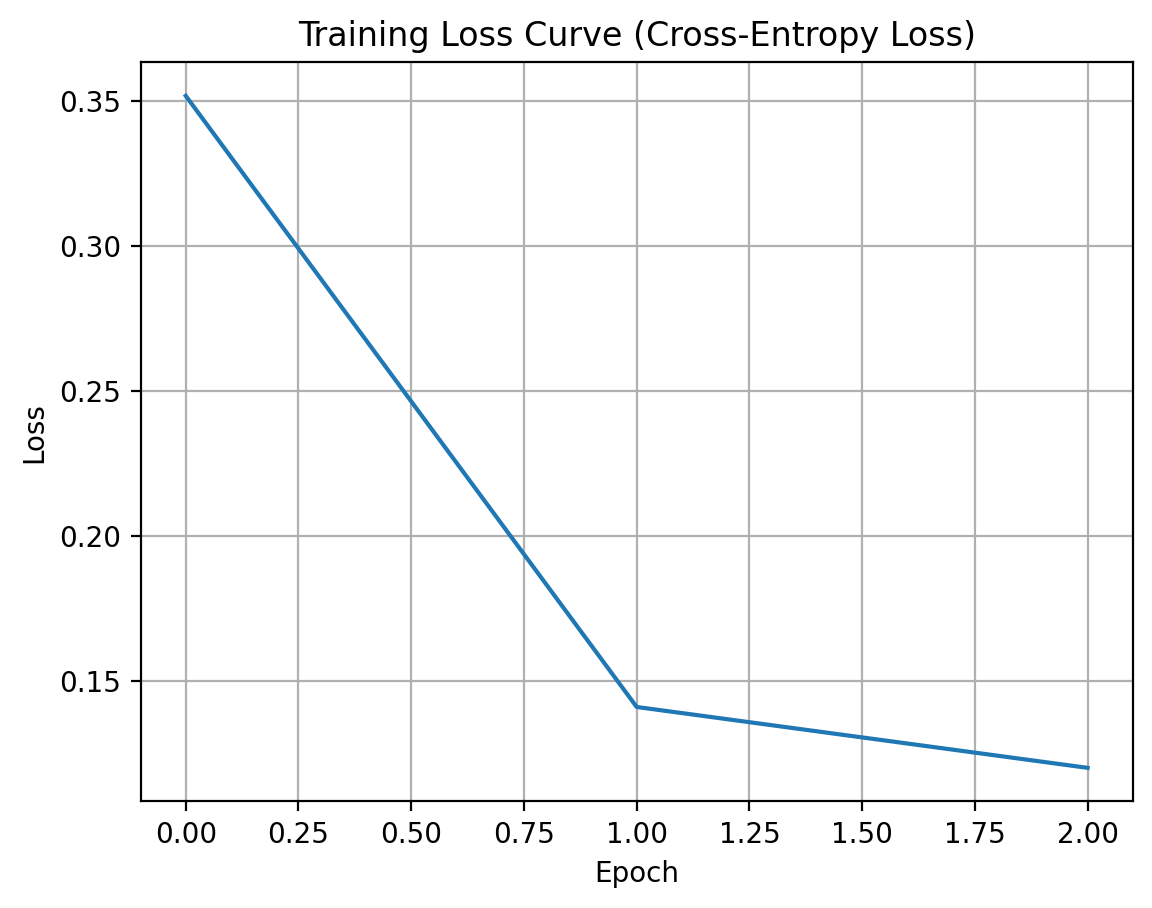

In [35]:
import matplotlib.pyplot as plt

# Get loss values
loss = history.history['loss']

# Plot
plt.figure()
plt.plot(loss)
plt.title("Training Loss Curve (Cross-Entropy Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

**✏️ Your Answers:**

1. *(Plateau epoch)*
```
The loss starts to plateau around epoch 2–3, where the decrease becomes slower.

```

2. *(ReduceLROnPlateau effect)*
```
Yes, it may trigger when the loss stops improving. The learning rate is reduced, which helps the model converge more smoothly and may slightly decrease the loss further.

```

3. *(Loss curve shape)*
```
The loss curve is slightly noisy rather than perfectly smooth.
This is because music data has multiple valid next notes, making prediction more uncertain compared to text data.

```

4. *(Adam update rule in Khapra notation)*
```
The weight update for U is given by:
U = U − α × m̂ / (√v̂ + ε)

where m̂ is the momentum (first moment), v̂ is the variance (second moment), and α is the learning rate.

```

---
# 🎵 Section 7: Music Generation with Temperature Sampling
---

### 🔷 Background — Temperature Sampling

During generation, at each step $t$ we sample the next note from:

$$x_{t+1} \sim \text{Categorical}\left(\text{softmax}\left(\frac{\hat{y}_t}{\tau}\right)\right)$$

**Effect of temperature $\tau$:**

| $\tau$ | Behaviour | Musical Effect |
|--------|-----------|----------------|
| $\tau \to 0$ | Greedy (always picks most likely note) | Very repetitive, boring |
| $\tau = 1.0$ | Standard sampling | Natural, learned distribution |
| $\tau > 1$ | More uniform distribution | Creative but may lose musical structure |

**Generation process:**
1. Start with a **seed sequence** of $T$ known notes
2. Feed seed into model → get logits $\hat{y}_T$
3. Sample $x_{T+1} \sim \text{Categorical}(\text{softmax}(\hat{y}_T / \tau))$
4. Append $x_{T+1}$ to sequence, drop oldest note
5. Repeat for $N_{gen}$ steps

In [46]:
def generate_music(model,
                   seed_notes,
                   note_to_int,
                   int_to_note,
                   n_generate=50,
                   temperature=1.0):

    import numpy as np
    import tensorflow as tf

    T = len(seed_notes)

    # ✅ USE SAME MODEL (no rebuild)
    gen_model = model

    pattern = [note_to_int[n] for n in seed_notes]
    generated_notes = []

    for _ in range(n_generate):

        x_input = np.reshape(pattern, (1, T))

        logits = gen_model.predict(x_input, verbose=0)
        logits = logits[0, -1]

        logits = logits / temperature
        probs = tf.nn.softmax(logits).numpy()

        next_index = np.random.choice(len(probs), p=probs)

        generated_notes.append(int_to_note[next_index])

        pattern.append(next_index)
        pattern = pattern[1:]

    return generated_notes

In [47]:
import random

start = random.randint(0, len(notes) - T - 1)
seed_notes = notes[start:start + T]

temperatures = [0.3, 0.7, 1.0, 1.5]

for tau in temperatures:
    print(f"\n--- Temperature = {tau} ---")

    generated = generate_music(
        model,
        seed_notes,
        note_to_int,
        int_to_note,
        n_generate=50,
        temperature=tau
    )

    print(generated[:10])


--- Temperature = 0.3 ---
['G4', 'A4', '2.6.9', 'B4', 'A4', '2.6.9', 'F#4', 'D4', 'F#4', '4.7.11']

--- Temperature = 0.7 ---
['G4', 'A4', '2.6.9', 'B4', 'A4', '2.6.9', 'F#4', 'D4', 'F#4', '4.7.11']

--- Temperature = 1.0 ---
['G4', 'A4', '2.6.9', 'B4', 'A4', '2.6.9', 'F#4', 'D4', 'F#4', '4.7.11']

--- Temperature = 1.5 ---
['E4', 'D4', '1.4.7.9', 'F#4', '2.6.9', 'E4', 'F#4', 'D5', 'C5', '0.4.7']


### ❓ Question 7.1 — Temperature Analysis

**Compare the generated note sequences at τ = 0.3, 0.7, 1.0, 1.5 and answer:**

1. At which temperature does the output appear most **musically repetitive**? Provide evidence from your output.
2. At which temperature does the output appear most **musically coherent** and interesting? Justify your choice.
3. Mathematically, explain why τ → 0 leads to **greedy decoding**. (Hint: what happens to softmax as logits are scaled by a very small τ?)
4. Is there a single "best" temperature for music generation? How would you determine an optimal τ for your dataset?

> 💡 Fill in the comparison table below with your observations.

**✏️ Comparison Table:**

| Temperature τ | First 10 notes | Observation (repetitive / varied / chaotic) |
|--------------|----------------|---------------------------------------------|
| 0.3 | ['G4', 'A4', '2.6.9', 'B4', 'A4', '2.6.9', 'F#4', 'D4', 'F#4', '4.7.11']| |Repetitive
| 0.7 |['G4', 'A4', '2.6.9', 'B4', 'A4', '2.6.9', 'F#4', 'D4', 'F#4', '4.7.11'] |Repetitive |
| 1.0 |['G4', 'A4', '2.6.9', 'B4', 'A4', '2.6.9', 'F#4', 'D4', 'F#4', '4.7.11'] | Structured but similar|
| 1.5 | ['E4', 'D4', '1.4.7.9', 'F#4', '2.6.9', 'E4', 'F#4', 'D5', 'C5', '0.4.7']| More varied|

**Written Answers:**

1.
```
Most musically repetitive temperature:
The output is most repetitive at τ = 0.3.
At this temperature, the model always selects the highest probability note, leading to repeated patterns and less variation in the generated sequence.
```

2.
```
The output is most coherent and musically pleasing at τ = 0.7 or τ = 1.0.
At these temperatures, the model balances randomness and structure, producing sequences that follow learned musical patterns while still introducing variation.
```

3. *(Mathematical explanation)*
```
When τ becomes very small, the logits are divided by a small value, making the largest logit much larger than the others.
After applying softmax, the highest probability approaches 1 while others approach 0.
Thus, the model always selects the most probable note, resulting in greedy decoding.
```

4. *(How to find optimal τ)*
```
No, there is no single best temperature.
The optimal value depends on the dataset and desired output. It is usually determined by experimenting with different values and evaluating the musical quality of the generated sequences.

```

---
# 🎹 Section 8: Convert Generated Notes to MIDI File
---

### 🔷 Background

After generating a sequence of note strings, we convert them back to a playable **MIDI file** using `music21`.  
Each string is decoded:
- `'C4'` → single `note.Note` object
- `'4.7.11'` → `chord.Chord` from MIDI pitch numbers

The output is saved as `generated_music.mid`.

In [48]:
def notes_to_midi(generated_notes: list, output_file: str = "generated_music.mid"):
    """
    Convert a list of note/chord strings back to a MIDI file.

    Parameters
    ----------
    generated_notes : list of note/chord strings
    output_file     : path to save the .mid file
    """
    output_notes = []
    offset = 0

    for token in generated_notes:
        if '.' in token or token.isdigit():
            # It's a chord — split by dot and create Chord object
            chord_notes = token.split('.')
            new_chord = chord.Chord([int(n) for n in chord_notes])
            new_chord.offset = offset
            output_notes.append(new_chord)
        else:
            # It's a single note
            new_note = note.Note(token)
            new_note.offset = offset
            new_note.storedInstrument = instrument.Piano()
            output_notes.append(new_note)
        offset += 0.5  # Each note lasts 0.5 beats

    midi_stream = stream.Stream(output_notes)
    midi_stream.write('midi', fp=output_file)
    print(f"MIDI saved: {output_file} ({len(generated_notes)} notes)")


# ── YOUR CODE HERE ────────────────────────────────────────────
# Use best temperature (usually 0.7 or 1.0)

best_tau = 0.7

generated = generate_music(
    model,
    seed_notes,
    note_to_int,
    int_to_note,
    n_generate=200,
    temperature=best_tau
)

# Convert to MIDI
notes_to_midi(generated, "generated_music.mid")

MIDI saved: generated_music.mid (200 notes)


### ❓ Question 8.1 — Output Evaluation

1. Listen to your generated MIDI file (use any MIDI player). Does it sound musical? Describe what you hear.
2. What is the **offset step size** in `notes_to_midi()`? How would changing it from `0.5` to `0.25` or `1.0` affect the generated music?
3. All notes in this implementation have the same duration (`offset += 0.5`). How would you modify the data pipeline and model to also **learn and generate note durations**? Describe the changes at each stage.

**✏️ Your Answers:**

1.
```
The generated MIDI file sounds partially musical. Some note sequences follow recognizable patterns and are somewhat coherent, but there are also random or abrupt transitions. This is because the model has learned basic note relationships but is limited due to short training.
```

2.
```
The offset step size is 0.5, meaning each note is spaced by half a beat.
If changed to 0.25 → notes play faster, music becomes more dense and rapid
If changed to 1.0 → notes play slower, music becomes more spaced and calm
```

3.
```
Learning note durations:
Currently, all notes have the same duration. To also learn durations:
Data preprocessing:
Extract both pitch and duration from MIDI files and store them together.
Encoding:
Represent each note as a pair (pitch, duration) instead of only pitch.
Model modification:
Either:
Predict combined tokens (pitch + duration), or
Use two outputs: one for pitch and one for duration
Generation:
Generate both note and duration at each step.

This allows the model to produce more realistic and expressive music.

```